In [2]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours
from tqdm.notebook import tqdm
import sys

plt.rcParams["figure.dpi"] = 150

In [3]:
def localized_state(size):
    psi0 = np.zeros(size, dtype = complex)
    beg = int(0.35*size)
    end = int(0.65*size)
    psi0[beg:end] = np.random.uniform(-1, 1, end-beg) + 1j * np.random.uniform(-1, 1, end-beg)
    psi0 /= np.linalg.norm(psi0)
    
    return psi0

def time_evol(U, n, psi0):

    for _ in range(1, n):
        psi = U@psi0
        psi0 = psi

    return psi

def coupling_dependence(N, kappas, alpha, beta):

    neg = np.zeros(len(kappas))
    for i, g in enumerate(tqdm(range(len(kappas)), desc="coupling")):
        U = diagonalize_floquet_operator(N, alpha, beta, kappas[i])
        psi0 = localized_state(N)
        psi = time_evol(U, 10, psi0)
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real
        neg[i] = np.sum(np.abs(W) - W)/2
        psi0 = psi

    return neg

In [4]:
def plot(kappas, N, params):
    n = len(params)
    ncols = 3                      # adjust if you want
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (alpha, beta) in zip(axes, params):
        neg = coupling_dependence(N, kappas, alpha, beta)
        ax.scatter(np.log(kappas), np.log(neg))
        ax.set_title(rf"$\alpha={alpha},\,\beta={beta}$")
        ax.set_xlabel(r"$\log(\kappa)$")
        ax.set_ylabel(r"$\log(\mathrm{Negativity})$")

    # turn off unused axes
    for ax in axes[len(params):]:
        ax.axis("off")

    fig.suptitle(rf"$N = {N}$", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

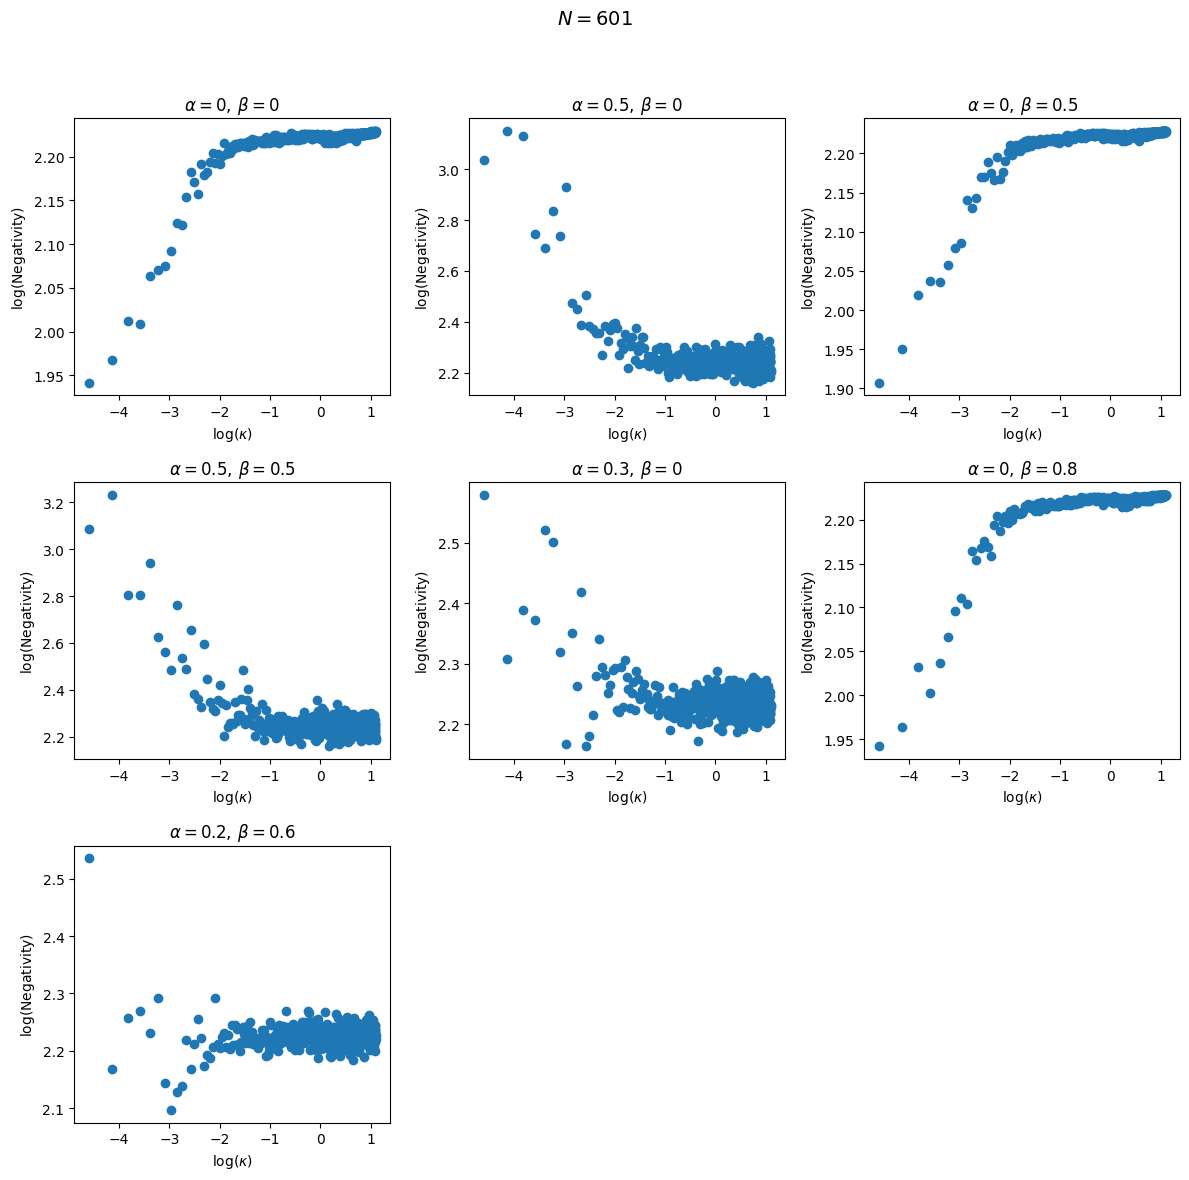

In [4]:
kappas = np.linspace(0.01, 3, 500)
params = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(kappas, 601, params)

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

coupling:   0%|          | 0/500 [00:00<?, ?it/s]

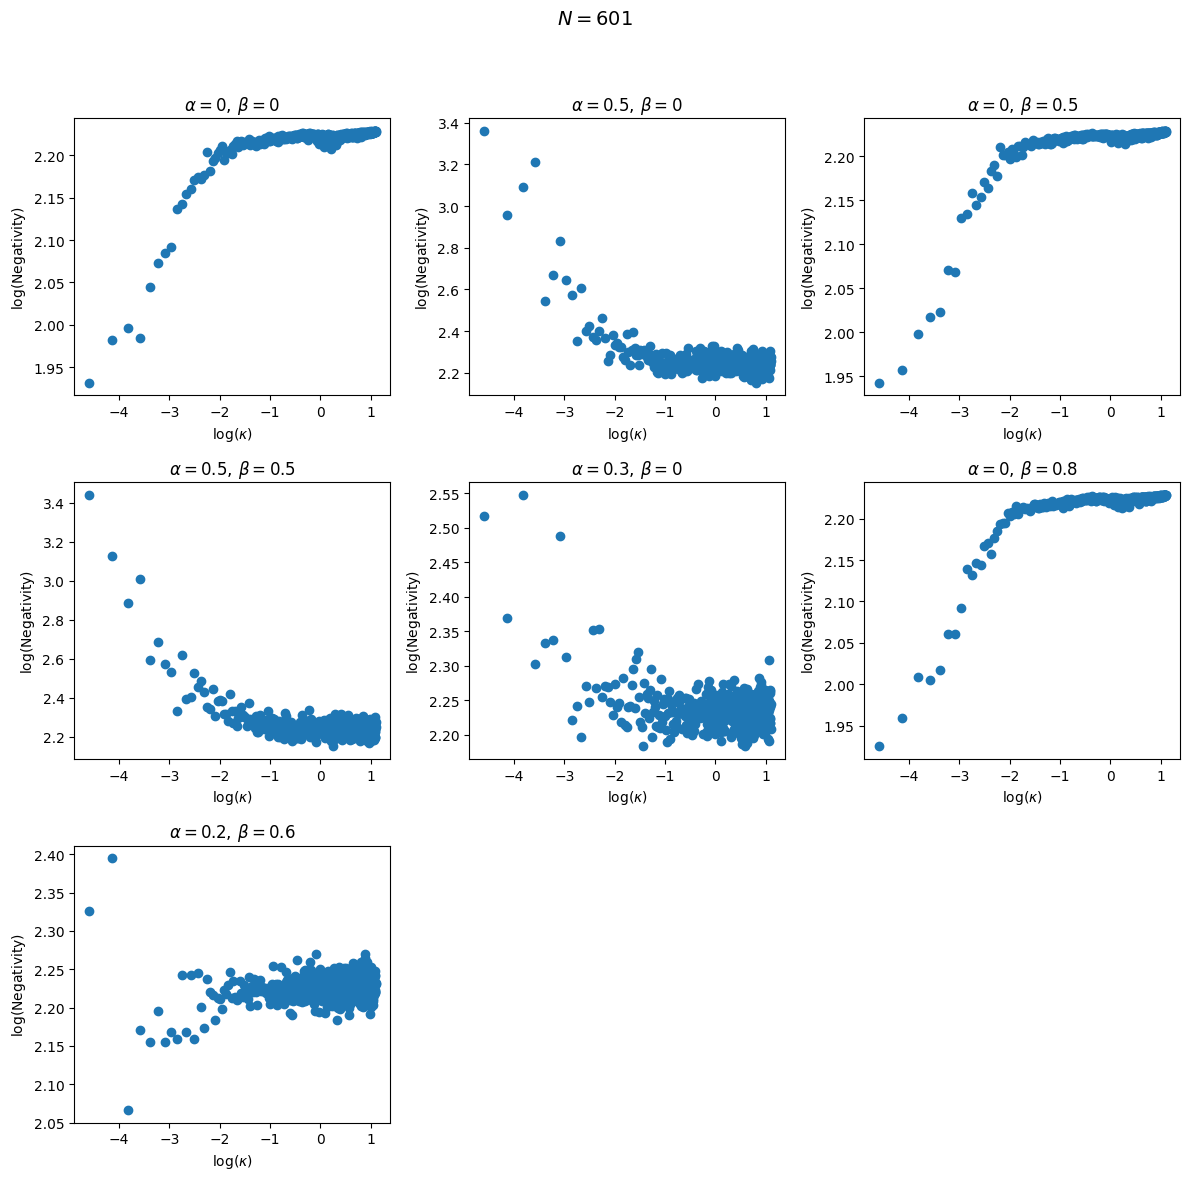

In [5]:
kappas = np.linspace(0.01, 3, 500)
params = [(0, 0),(0.5, 0),(0, 0.5),(0.5, 0.5),(0.3, 0),(0, 0.8),(0.2, 0.6)]

plot(kappas, 601, params)

Check behaviour for near integrable and maximally chaotic state

In [5]:
alpha_int = 0; beta_int = 0
alpha_chaotic = 0.2; beta_chaotic = 0.6
N = 601
kappas = np.linspace(0.01, 10, 1000)

In [6]:
neg_int = coupling_dependence(N, kappas, beta_int, alpha_int)
neg_chaotic = coupling_dependence(N, kappas, beta_chaotic, alpha_chaotic)

coupling:   0%|          | 0/1000 [00:00<?, ?it/s]

coupling:   0%|          | 0/1000 [00:00<?, ?it/s]

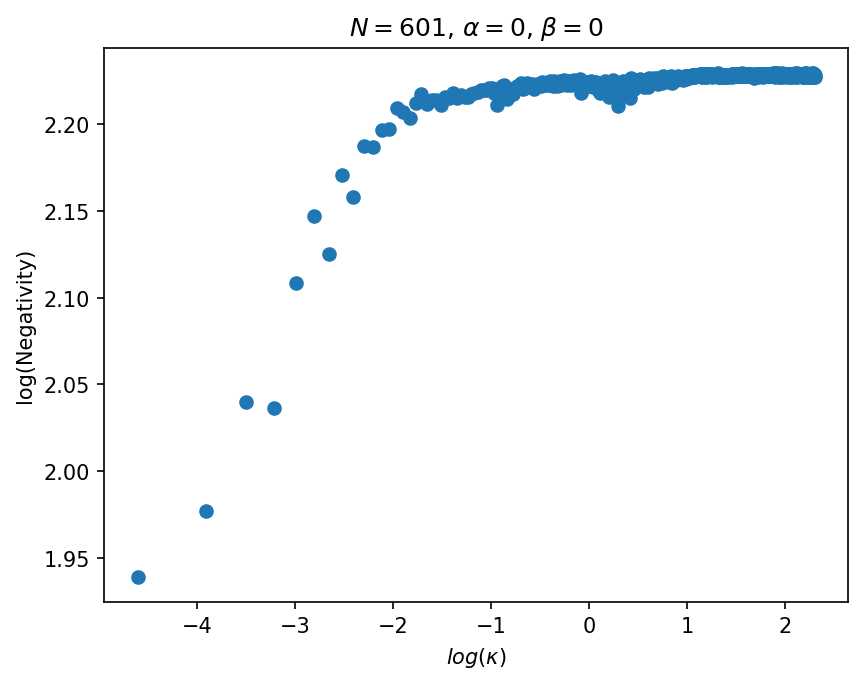

In [7]:
plt.scatter(np.log(kappas), np.log(neg_int))
plt.xlabel(rf"$log(\kappa)$")
plt.ylabel(r"log(Negativity)")
plt.title(rf"$N = {N}$, $\alpha = {beta_int}$, $\beta = {alpha_int}$")
plt.show()

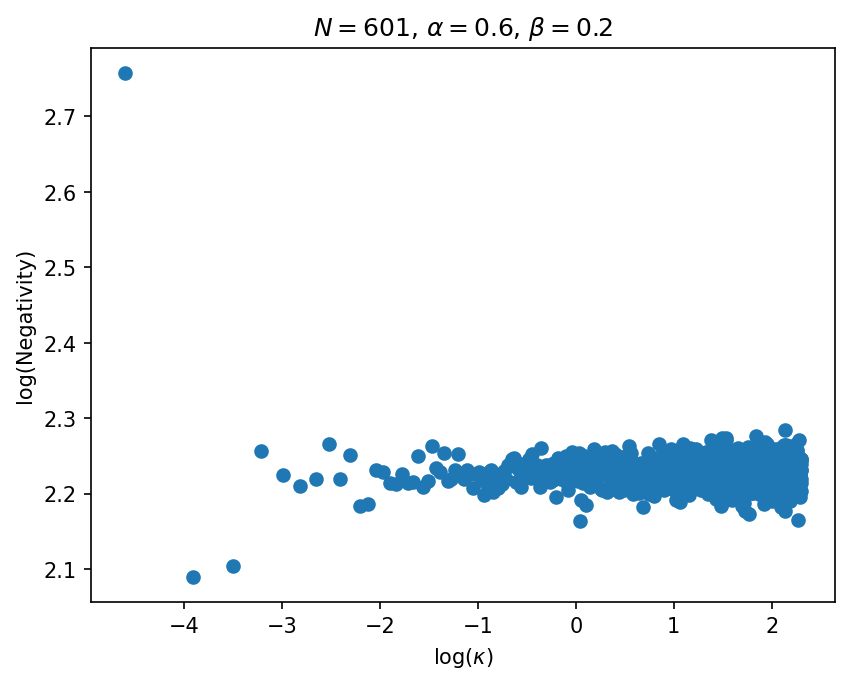

In [8]:
plt.scatter(np.log(kappas), np.log(neg_chaotic))
plt.xlabel(rf"$\log(\kappa)$")
plt.ylabel(r"log(Negativity)")
plt.title(rf"$N = {N}$, $\alpha = {beta_chaotic}$, $\beta = {alpha_chaotic}$")
plt.show()